In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from rich import print

import ewatercycle
import ewatercycle.forcing

In [7]:
shape_file_name = "CatchmentArea"

calibration_start_date = "1975-01-01T00:00:00Z"
calibration_end_date = "2010-12-31T00:00:00Z"

forcing_path_ERA5 = Path.home() / "BEP-beau/BEP/code" / "CatchmentArea" / "ERA5" / "own_shapefile"
forcing_path_ERA5.mkdir(exist_ok=True, parents=True)

In [8]:
shapefile_path =  Path.home() / "BEP-beau/BEP/code/CatchmentArea" / "CatchmentArea_4326.shp"

In [9]:
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
   dataset="ERA5",
   start_time=calibration_start_date,
   end_time=calibration_end_date,
   shape=shapefile_path,
   directory=forcing_path_ERA5,
)

In [10]:
print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='1975-01-01T00:00:00Z',
    end_time='2010-12-31T00:00:00Z',
    directory=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/ERA5/own_shapefile/work/diagnostic/script'),
    shape=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/CatchmentArea_4326.shp'),
    filenames={
        'pr': 'OBS6_ERA5_reanaly_1_day_pr_1975-2010.nc',
        'tas': 'OBS6_ERA5_reanaly_1_day_tas_1975-2010.nc',
        'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_1975-2010.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

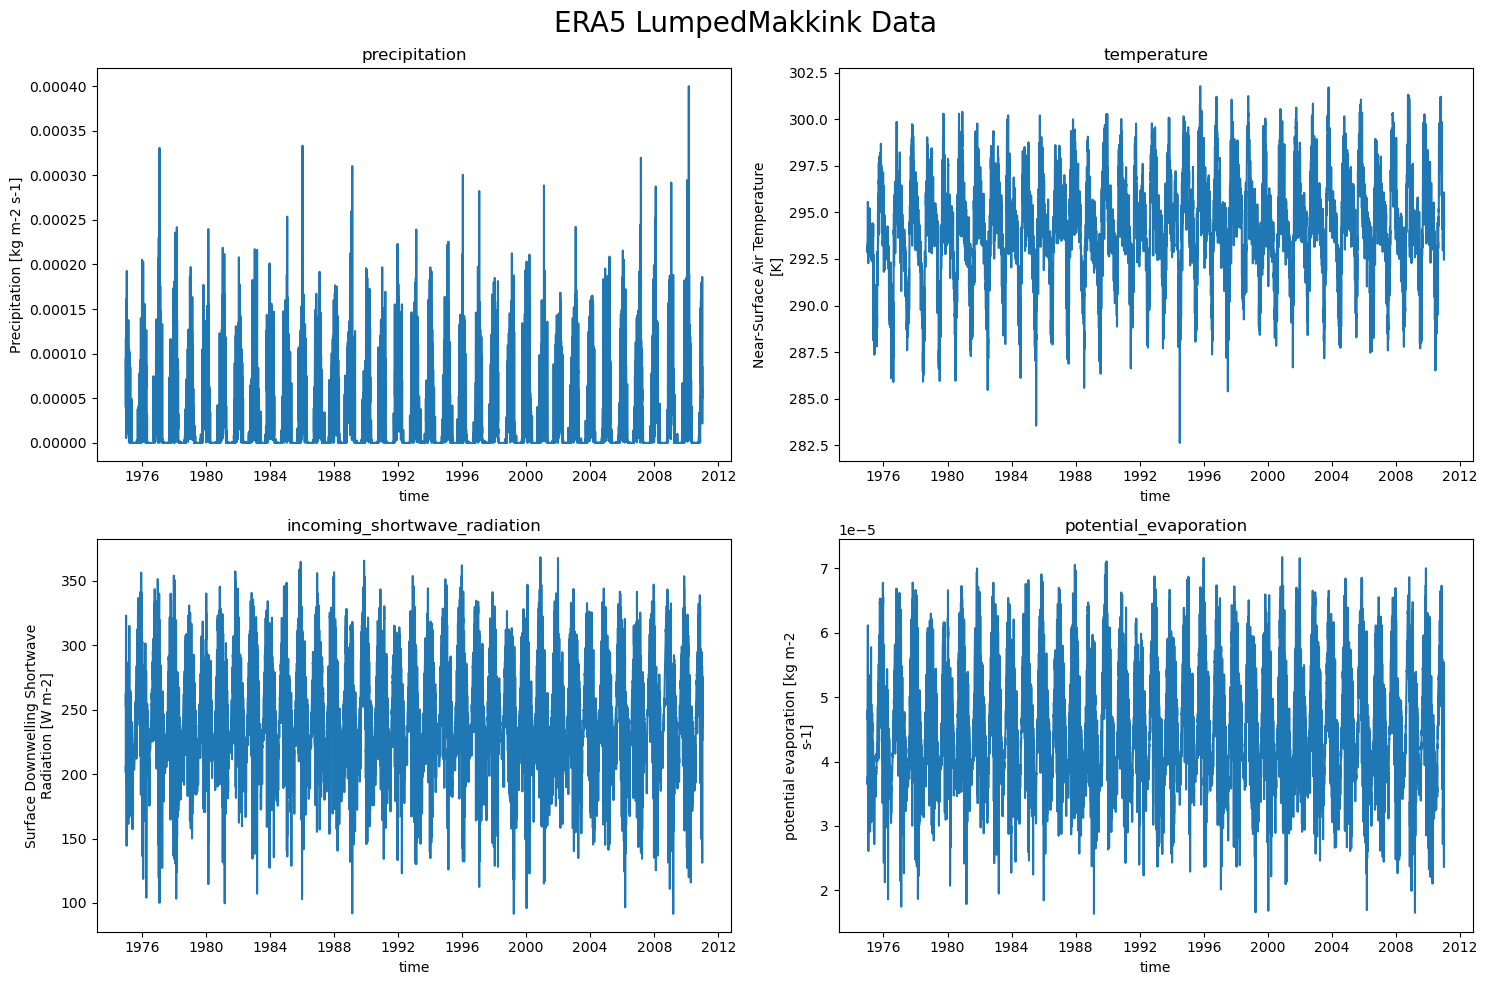

In [13]:
ERA5_data = {'precipitation pr': xr.open_dataset(ERA5_forcing['pr']),
             'temperature tas': xr.open_dataset(ERA5_forcing['tas']),
             'incoming_shortwave_radiation rsds': xr.open_dataset(ERA5_forcing['rsds']),
             'potential_evaporation evspsblpot': xr.open_dataset(ERA5_forcing['evspsblpot'])
}

plot_counter = 1
plt.figure(figsize=(15, 10))
for name, data in ERA5_data.items():
    plt.subplot(2,2, plot_counter)
    data[name.split(" ")[-1]].plot()
    plt.title(f"{name.split(" ")[0]}")
    plot_counter += 1

plt.suptitle("ERA5 LumpedMakkink Data", fontsize=20)
plt.tight_layout()